URl= https://www.kaggle.com/code/mpwolke/to-buy-or-not-to-buy-ev
Title: To buy, or Not to buy (EV)?

In [5]:
# 필요한 모듈 다운로드
import pandas as pd
import numpy as np

In [3]:
# 데이터 다운로드
import kagglehub
kagglehub.login()

In [4]:
path = kagglehub.competition_download(
    "playground-series-s6e9",
    force_download=True
)

print("Path to competition files:", path)

100%|██████████| 14.1M/14.1M [00:01<00:00, 9.86MB/s]

Extracting files...


Path to competition files: C:\Users\이진섭\.cache\kagglehub\competitions\playground-series-s6e9


In [7]:
# 데이터 변수명 설정
train=pd.read_csv(r'C:\Git_for_study\DE\Practice\Kaggle\Data\EV car\train.csv')
test=pd.read_csv(r'C:\Git_for_study\DE\Practice\Kaggle\Data\EV car\test.csv')
sub=pd.read_csv(r'C:\Git_for_study\DE\Practice\Kaggle\Data\EV car\sample_submission.csv')

In [10]:
train.tail(3)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No
668664,668664,54,68986.0,5.0,1,6,9,2.0,Male,Urban,Hatchback,No,Yes,Low,No


In [9]:
# 데이터 정보
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [11]:
sub.head(3)

,id,Will_Buy_EV
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645


In [12]:
#머신러닝 모듈 임포트
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

C:\Users\이진섭\AppData\Local\Temp\ipykernel_17860\3534943400.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Will_Buy_EV', data=train, palette='summer')


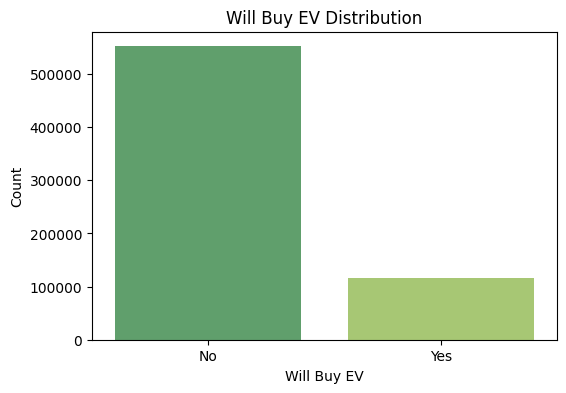

In [13]:
# 데이터 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='Will_Buy_EV', data=train, palette='summer')
plt.title('Will Buy EV Distribution')
plt.xlabel('Will Buy EV')
plt.ylabel('Count')
plt.show()

<Axes: >

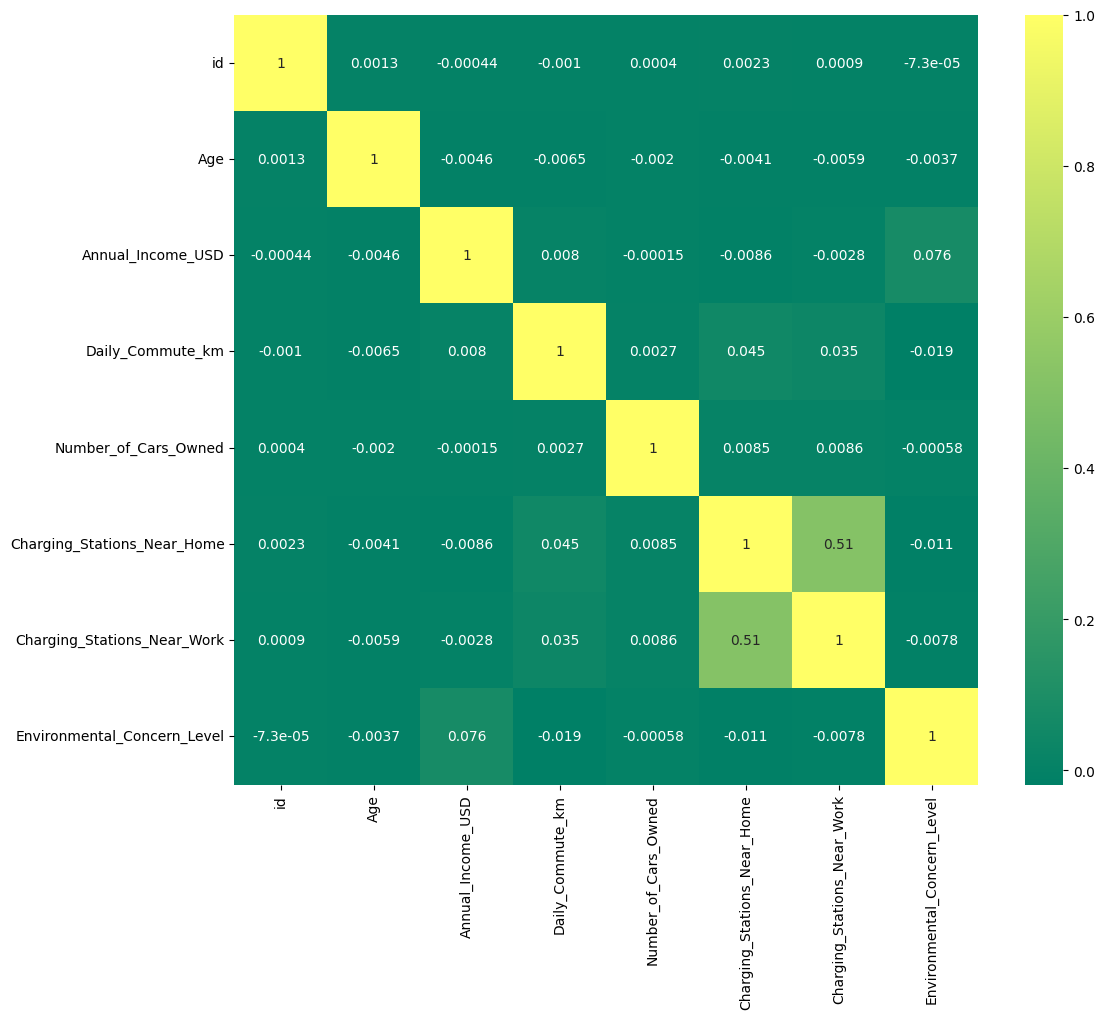

In [14]:
# 히트맵 : 변수간 상관관계를 시각화 하기 위함

plt.figure(figsize=(12,10))
sns.heatmap(train.select_dtypes(include='number').corr(), annot=True, cmap='summer')

In [ ]:
# 데이터 전처리
# 1입력변수와 결과 분리
X=train.drop(columns=['id', 'Will_Buy_EV'])
y=train['Will_Buy_EV']

#2 명목형 변수 중 텍스트를 숫자로 변환
X=pd.get_dummies(X, drop_first=True).astype(int)
y=pd.get_dummies(y, drop_first=True).astype(int).values.ravel()

# ==> 범주 열 중 하나를 제거하는 이유는 선형/로지스틱 회귀와 같이 절편이 있는 모델에서 발생할 수 있는 완전 다중공선성(dummy variabvle trap)을 피하려는 목적
# ravel은 다차원 배열을 1차원 배열로 평탄화하는 것 valus는 인덱스의 열과 이름을 제외하고 넘파이 배열만 가져옴

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

# StandardScaler에서 변환하면 넘파이로 변환되는 데 이는 사키잇런이 행렬 기반의 연산을 효율적으로 진행하기 때문임
#-> train 데이터에 fit_transform을 적용하여 데이터들의 평균과 표준편차를 학습시 킨 후에, test 데이터에는 기존에 학습된 데이터를 기반으로 transform만 진행해야 한다. 그렇지 않으면 데이터 누수발생


In [21]:
X_train, X_test, y_train, y_test=train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# 로지스틱회귀에 적합
model=LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred=model.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110540
           1       0.72      0.66      0.69     23193

    accuracy                           0.90    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.90      0.89    133733

Confusion Matrix:
[[104520   6020]
 [  7905  15288]]


결과 해석: 
전체 정확도는 0.90이지만 클래스별 불균형이 큰 상태, 데이터가 클래스 0에 치우쳐져 있어 accuracy만으로는 성능을 판단하면 과대평가가 됨

클래스 0,1 중 어떤 것을 맞추는 게 더 비용적으로 손해/이익인지를 판단한 지에 따라서 모델과 임계값을 튜닝행 함
현재 상태에서는 데이터가 많은 0을 맞추는 거에 익숙해져 있으므로 1을 맞추는 데에 익숙해지도록 모델을 변경해야 함

macro_avg란? :클래스 0과 클래스 1을 동등하게 취급한 단순 평균
weighted_avg : 각 클래스의 표본수에 비례한 가중평균

신뢰도란? : 특정 예측이 해당 클래스일 것이라고 모델이 얼마나 확신하느 가를 보여주느 지표



In [25]:
model=LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred=model.predict(X_test)

In [27]:
print('Classification Report:')
print(classification_report(y_test, y_pred))

print('Confusion_matrix:')
print(confusion_matrix(y_test,y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91    110540
           1       0.55      0.90      0.69     23193

    accuracy                           0.86    133733
   macro avg       0.76      0.87      0.80    133733
weighted avg       0.90      0.86      0.87    133733

Confusion_matrix:
[[93858 16682]
 [ 2403 20790]]


C:\Users\이진섭\AppData\Local\Temp\ipykernel_17860\1622819317.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='summer')


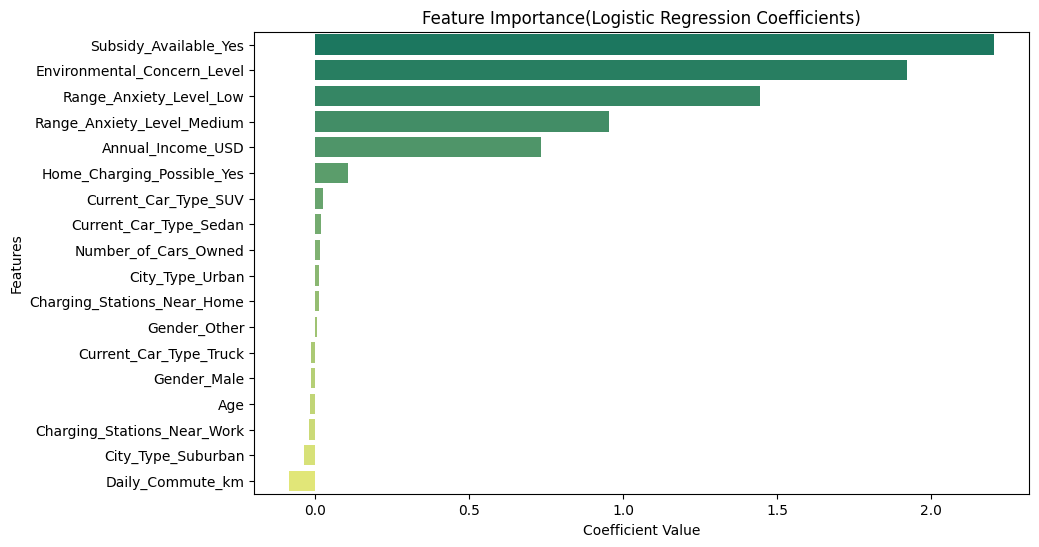

In [28]:
feature_names=X.columns
coefficients=model.coef_[0]

coef_df=pd.DataFrame({
    'Feature':feature_names,
    'Coefficient':coefficients
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='summer')
plt.title('Feature Importance(Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

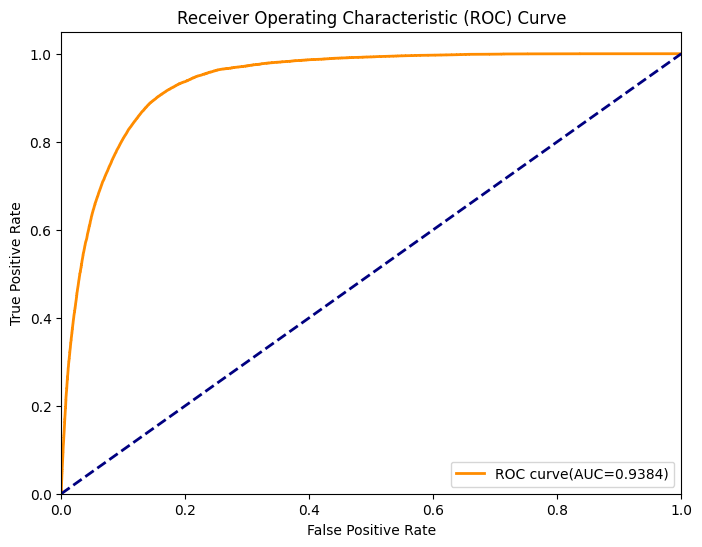

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba=model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds=roc_curve(y_test, y_pred_proba)
auc_score=roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve(AUC={auc_score:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()